⏳ Đang chuẩn bị chuỗi thời gian...
✅ Chuỗi thời gian đã gộp theo ngày. Tổng số ngày: 4019
⏳ Đang vẽ biểu đồ ACF và PACF...


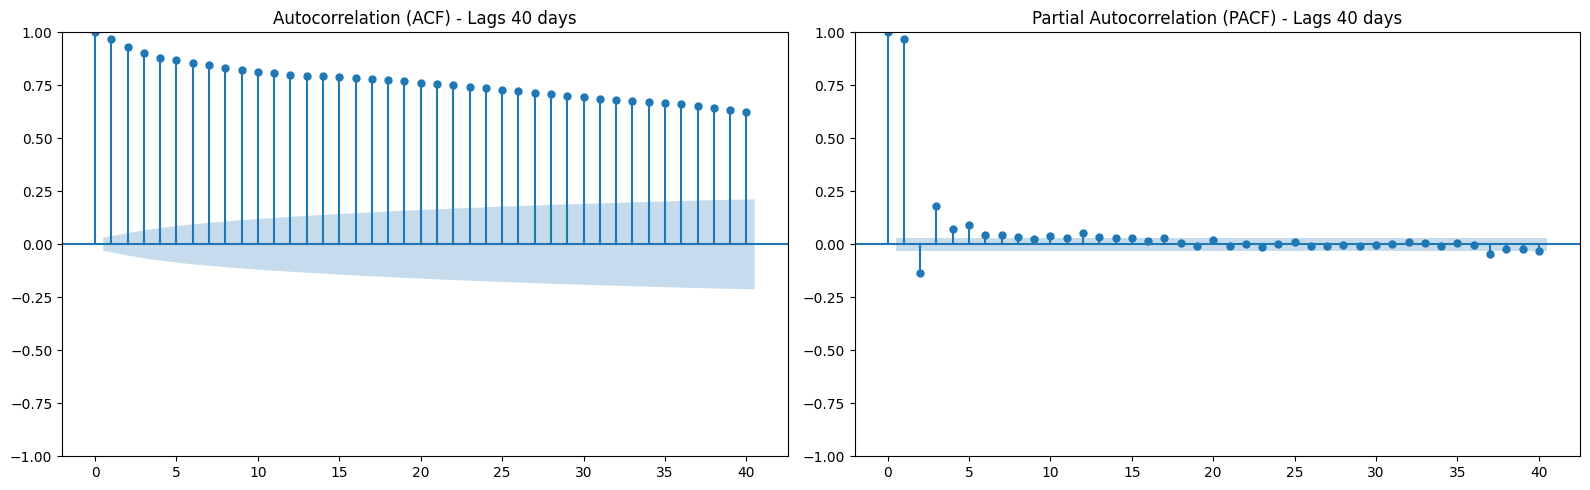

⏳ Đang huấn luyện Holt-Winters (Bắt chu kỳ 365 ngày) trên 3215 ngày...
⏳ Đang dự báo trên tập Test...
✅ Đánh giá: MAE = 3.04°C | RMSE = 3.75°C


d:\khaiphadulieu\Du_Bao_Thoi_Tiet\venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


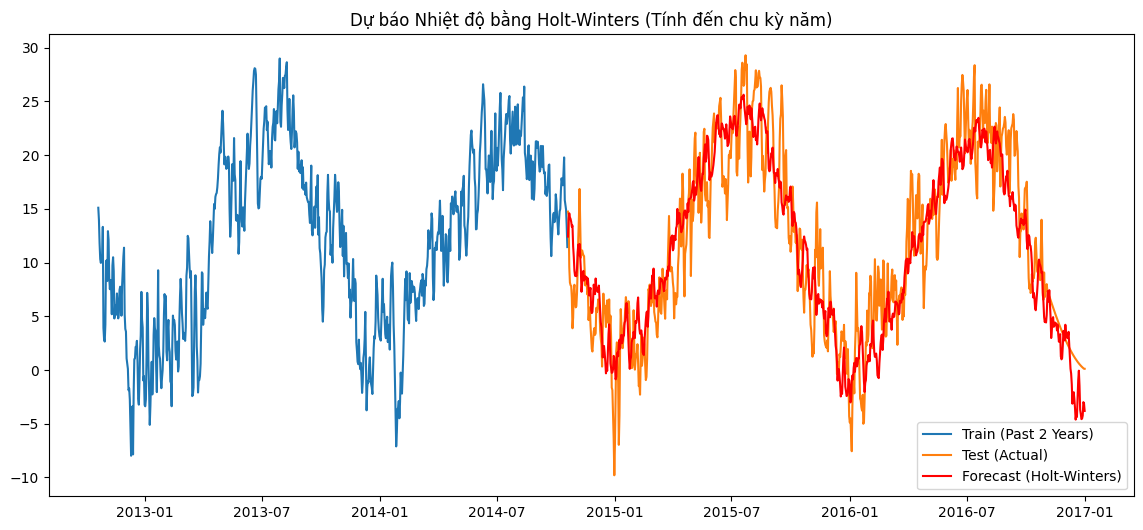

⏳ Đang chẩn đoán Phần dư (Residuals)...


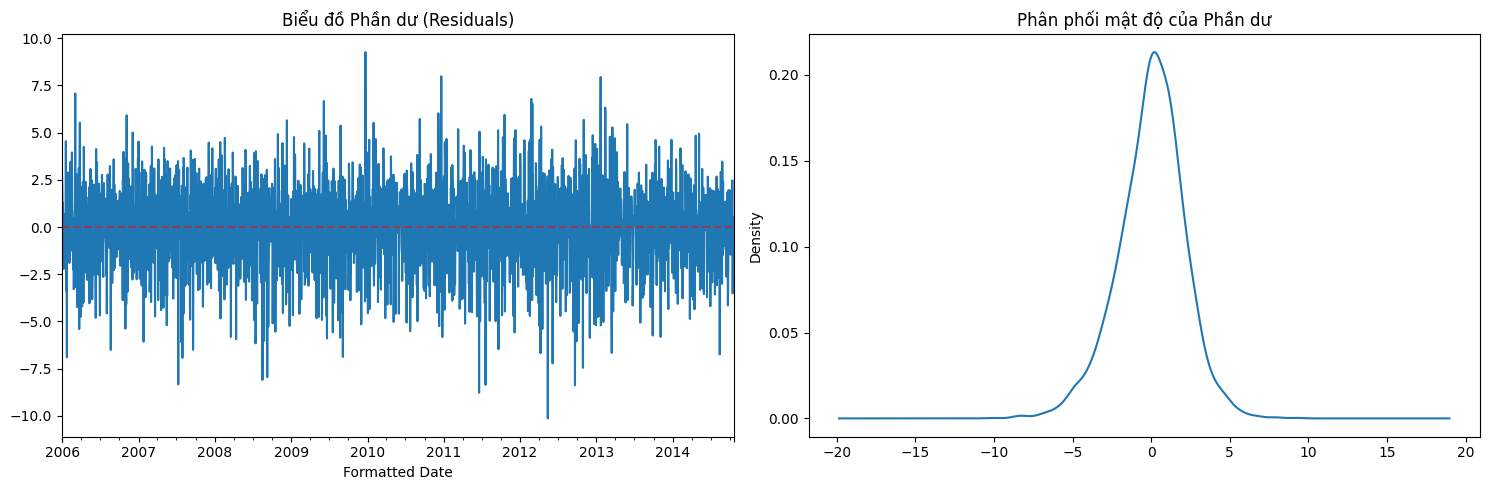

In [1]:
import os
import sys
import pandas as pd

if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

from src.time_series_models import WeatherTimeSeries
import yaml

# 1. Đọc dữ liệu
with open("configs/params.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)
df_clean = pd.read_csv(config['data']['processed_path'])

# 2. Khởi tạo module
ts_model = WeatherTimeSeries()

# 3. Chuẩn bị dữ liệu chuỗi thời gian (Daily)
ts_data = ts_model.prepare_time_series(df_clean)

# 4. Vẽ ACF và PACF để xác định bậc
ts_model.plot_acf_pacf(ts_data)

# 5. Thay vì gọi ARIMA, ta gọi Holt-Winters
test, forecast, fitted_model = ts_model.train_and_forecast_hw(ts_data)

# 6. Phân tích lại lỗi phần dư
ts_model.analyze_residuals(fitted_model)